**Проект Т-Банк: использование сервисов Города**




Целью данного исследования являлся анализ структуры выручки маркетплейса с целью выявления характера её распределения между продавцами, оценки уровня концентрации продаж и определения возможного географического дисбаланса между спросом и предложением. В рамках проекта необходимо было понять, насколько равномерно распределяются доходы внутри платформы и существует ли зависимость бизнеса от ограниченного числа участников или регионов.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving SQL сырые данные.xlsx to SQL сырые данные (2).xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = 'SQL сырые данные.xlsx'
dfs = pd.read_excel(file_path,sheet_name = None)
dfs.keys()

dict_keys(['products', 'sellers', 'cities', 'users', 'transactions'])

sheet_name = None потому что нам не важен лист с конкретным именем, нам нужны все листы из документа Excel.

dfs.keys() показывает названия колонок

In [4]:
import sqlite3
conn = sqlite3.connect("project.db")

In [5]:
for sheet_name, df in dfs.items():
  table_name = sheet_name
  df.to_sql(table_name, conn, if_exists = "replace", index = False)




**df.to_sql(table_name, conn, if_exists = "replace", index = False)**

pandas берёт DataFrame

создаёт SQL-таблицу

автоматически определяет типы столбцов

вставляет данные

**conn** - объект соединения, определяет к какой базе данных обращаться

**if_exists** = "replace" если существует таблица - заменить, или append - добавить в конец данные

*index = False* убирает нумерацию строк

'*products*': id	seller_id	price,

'sellers': id	name	city_id ,

'cities': id	name ,

'users': id	created_at	name	city_id,

'transactions': id  created_at	   status	   user_id	    product_id


In [6]:
query = """
select distinct status from transactions

limit 50
"""
result = pd.read_sql(query,conn)
result.head()


,status
0,pending
1,completed
2,error


pandas берёт строку query

через conn отправляет её в SQLite

SQLite выполняет SELECT

возвращает строки

pandas упаковывает их в DataFrame

Поэтому result — это обычный pandas DataFrame.


In [7]:
pd.read_sql("""
select status, count(status) cnt_trans from transactions
group by status
""",conn)

,status,cnt_trans
0,completed,1540
1,error,720
2,pending,740


In [8]:
query = """
SELECT
    sum(case when status = 'completed' then 1 else 0 end)* 1.0 /count(id)
    from transactions
"""
pd.read_sql(query, conn)

,sum(case when status = 'completed' then 1 else 0 end)* 1.0 /count(id)
0,0.513333


In [9]:
query = """
SELECT
    sum(p.price) AS total_revenue
from transactions t
JOIN products p
    ON t.product_id = p.id
where t.status = 'completed'
"""
pd.read_sql(query, conn)

,total_revenue
0,8041833


к таблице с транзакциями заджойнили таблицу с продуктами, соединив по id, чтобы посчитать сколько денег принесла продажа всех товаров.

In [10]:
query = """
select sum(p.price)*1.0 /
 count(*)

   from transactions t left join products p
   on t.product_id = p.id
   where t.status = 'completed'
"""
pd.read_sql(query, conn)

,sum(p.price)*1.0 /\n count(*)
0,5096.218631


посчитали средний чек. соединил значения из двух таблиц по айди продуктов.

In [11]:
query = """
select c.name, sum(p.price) sm

    from transactions t
    left join users u
    on t.user_id = u.id
    left join cities c
    on u.city_id = c.id
    join products p
    on t.product_id = p.id

where t.status = 'completed'
group by c.name
order by sm desc
"""
pd.read_sql(query, conn)

,name,sm
0,Velikiy Novgorod,677961
1,Sochi,640269
2,Bryansk,607251
3,Well,558232
4,Nizhny Novgorod,557690
5,Tver,551543
6,St. Petersburg,540452
7,Tula,533276
8,Samara,530063
9,Krasnodar,529032


посчитали выручку по городам. соединили таблицу с транзакциями чтобы получить оттуда статус выполненого заказа с таблицей юзеров, чтобы выбрать всех юзеров с завершенными заказами.

In [12]:
query = """
select c.name
from sellers s left join cities c
on s.city_id = c.id
group by c.name

"""
pd.read_sql(query, conn)

,name
0,Moscow
1,St. Petersburg
2,Yekaterinburg


'*products*': id	seller_id	price,

'sellers': id	name	city_id ,

'cities': id	name ,

'users': id	created_at	name	city_id,

'transactions': id  created_at	   status	   user_id	    product_id


In [13]:
query = """
select c.name, sum(p.price) sm

    from transactions t
    left join products p
    on t.product_id = p.id
    left join sellers s
    on p.seller_id = s.id
    left join cities c
    on s.city_id = c.id
where t.status = 'completed'
group by c.name
order by sm desc
"""
pd.read_sql(query, conn)

,name,sm
0,Moscow,4226061
1,St. Petersburg,3360504
2,Yekaterinburg,455268


тут мы посчитали выручку по каждому селлеру в каждом из городов

In [14]:
query = """
with revenue_by_city AS (
    -- считаем выручку по городам
    select
        c.name as city,
        sum(p.price) AS revenue
    from transactions t
    join products p on t.product_id = p.id
    join sellers s on p.seller_id = s.id
    join cities c on s.city_id = c.id
    where t.status = 'completed'
    group by c.name
),

total_revenue as (
    -- считаем общую выручку
    select sum(revenue) as total
    from revenue_by_city
)

-- основной запрос
select
    r.city,
    r.revenue,
    r.revenue * 1.0 / tr.total as revenue_share
from revenue_by_city r
cross join total_revenue tr
order by r.revenue desc;
"""
pd.read_sql(query, conn)

,city,revenue,revenue_share
0,Moscow,4226061,0.525510
1,St. Petersburg,3360504,0.417878
2,Yekaterinburg,455268,0.056612


Первый CTE

Создаёт таблицу:

| city | revenue |


 Второй CTE

Берёт сумму из первого CTE.

CROSS JOIN


total_revenue — это одна строка

надо приклеить её к каждой строке revenue_by_city

Это стандартный паттерн.

In [29]:
query_sellers = """
select
    s.id as seller_id,
    sum(p.price) as revenue,
    count(*) as sales_cnt,
    sum(p.price) * 1.0 / count(*) as avg_check
from transactions t
join products p on t.product_id = p.id
join sellers s on p.seller_id = s.id
where t.status = 'completed'
group by s.id
order by revenue desc
"""

df_sellers = pd.read_sql(query_sellers, conn)
df_sellers

,seller_id,revenue,sales_cnt,avg_check
0,mf11168ca,2748746,533,5157.121951
1,jh96638lo,1713554,343,4995.784257
2,sc95048sq,703100,115,6113.913043
3,pl96688ff,702207,124,5662.959677
4,cj77168kk,611758,119,5140.823529
5,hp268eb,485848,83,5853.590361
6,zv52168jf,477019,106,4500.179245
7,io51888xa,275222,60,4587.033333
8,cs46958te,180046,48,3750.958333
9,nd34058jl,144333,47,3070.914894


In [31]:
query_sellers_count = """
select count(distinct id) as sellers_cnt
from sellers
"""

df_sellers_count = pd.read_sql(query_sellers_count, conn)
df_sellers_count

,sellers_cnt
0,10


In [32]:
df_sellers = pd.read_sql(query, conn)

In [33]:
total_revenue = df_sellers['revenue'].sum()

top3_revenue = df_sellers.head(3)['revenue'].sum()

top3_share = round(top3_revenue / total_revenue,2)

top3_share

np.float64(0.64)

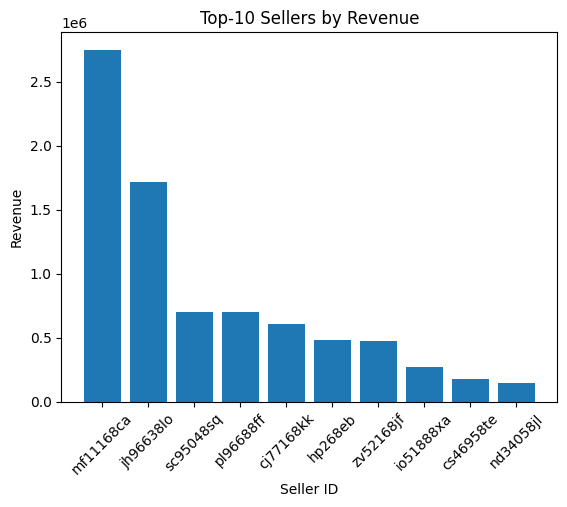

In [34]:
import matplotlib.pyplot as plt

top10 = df_sellers.head(10)

plt.figure()
plt.bar(top10['seller_id'], top10['revenue'])
plt.xticks(rotation=45)
plt.xlabel('Seller ID')
plt.ylabel('Revenue')
plt.title('Top-10 Sellers by Revenue')
plt.show()

посчитали суммарный доход, доход топ-3х продавцов и долю которую занимают топ 3

На основе этих данных можно сделать вывод о том, что рынок является крайне несбалансированным, так как всего 3 продавца фактически забрали себе почти 2/3 всей выручки, при общем количестве селлеров равном 10.

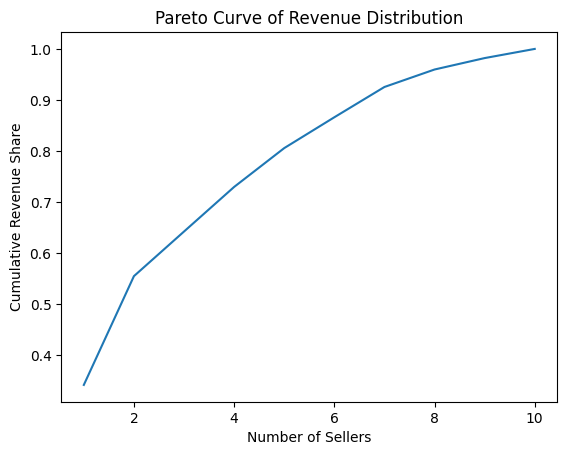

In [35]:


df_sorted = df_sellers.sort_values('revenue', ascending=False).reset_index(drop=True)

df_sorted['cum_share'] = df_sorted['revenue'].cumsum() / df_sorted['revenue'].sum()

plt.figure()
plt.plot(range(1, len(df_sorted)+1), df_sorted['cum_share'])
plt.xlabel('Number of Sellers')
plt.ylabel('Cumulative Revenue Share')
plt.title('Pareto Curve of Revenue Distribution')
plt.show()

Проведённый анализ показал, что структура выручки носит выраженно концентрированный характер. Несмотря на наличие десяти продавцов, значительная часть оборота сосредоточена у ограниченного числа участников: три продавца формируют около 64% всей выручки, а половина продавцов обеспечивает порядка 80% оборота. Кривая Парето подтверждает резкий рост кумулятивной доли на первых участниках распределения, что свидетельствует о высокой концентрации продаж и неравномерности распределения доходов.

Дополнительный географический анализ выявил различие между распределением спроса и предложения. Покупатели представлены в широком спектре городов, тогда как продавцы сосредоточены всего в трёх локациях. Это указывает на ограниченную географию предложения и потенциальный структурный дисбаланс между местами формирования спроса и местами генерации выручки.

Таким образом, рынок демонстрирует признаки структурной несбалансированности и зависимости от ограниченного числа ключевых продавцов. Подобная концентрация может создавать операционные и стратегические риски, связанные с высокой зависимостью бизнеса от отдельных участников. В целом поставленная цель проекта — определить структуру выручки и выявить концентрацию продаж и географические дисбалансы — была достигнута.



Что нужно учесть в будущем:

1. Каждому запросу нужно присваивать свое название для того, чтобы не возникало конфликтов.
2. Четко формулирую цель, метрики на начальном этапе.